### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [ ]:
data = pd.read_csv('coupons.csv')

In [ ]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [ ]:
data.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


3. Decide what to do about your missing data -- drop, replace, other...

If a value is missing (NaN) for a particular user in these frequency-related columns, it is a reasonable assumption that the user does not visit that type of establishment at all, or at least not regularly enough to have a recorded frequency.

In [ ]:
# Drop the 'car' column as it has a large number of missing values and is not explicitly mentioned as a required feature.
data = data.drop(columns=['car'])

# Fill missing values (NaN) in specific frequency-related columns with the string 'never'.
# This assumes that a missing value in these columns implies the user never visits that type of establishment.
data[['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']] = data[['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']].fillna('never')

# Print the sum of null values for the columns that were just imputed to verify the operation.
print(data.isnull().sum().loc[['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']])

Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
dtype: int64


4. What proportion of the total observations chose to accept the coupon?



In [ ]:
acceptance_proportion = data['Y'].mean()
print(f"Proportion of accepted coupons: {acceptance_proportion:.2f}")

Proportion of accepted coupons: 0.57


5. Use a bar plot to visualize the `coupon` column.

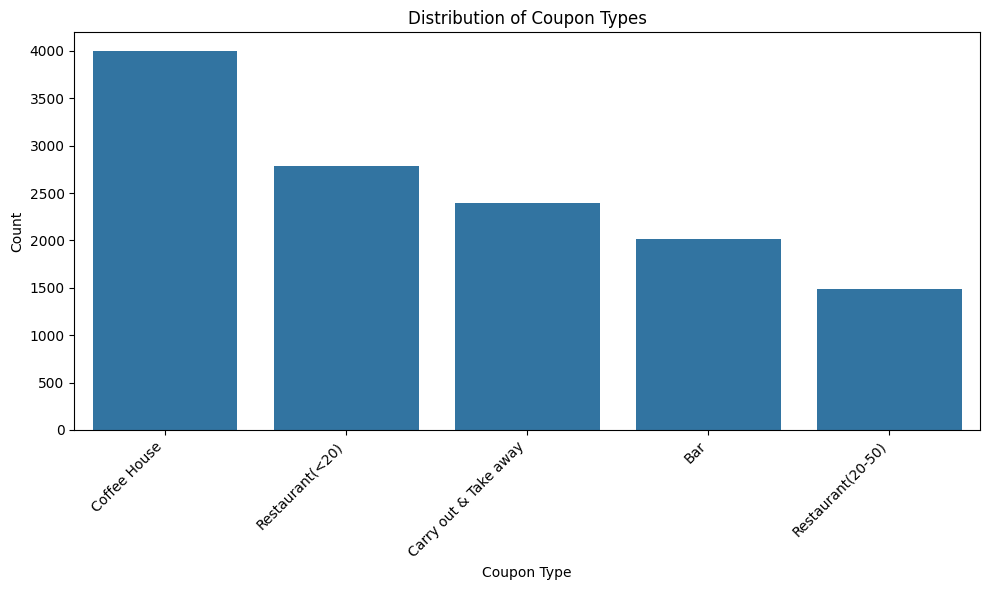

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='coupon', order=data['coupon'].value_counts().index)
plt.title('Distribution of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

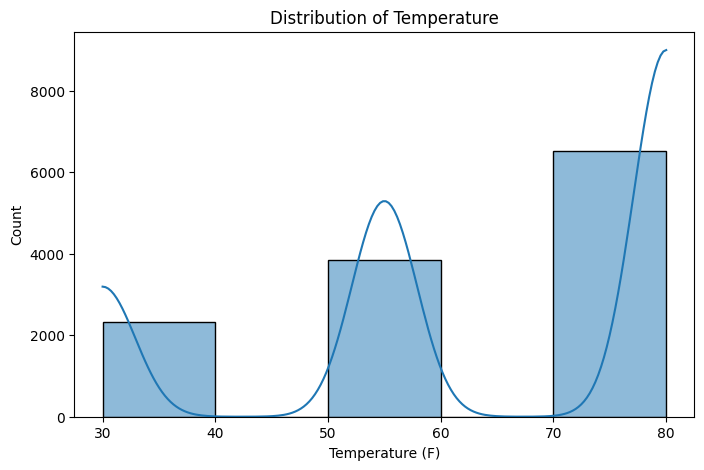

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=data, x='temperature', bins=5, kde=True)
plt.title('Distribution of Temperature')
plt.xlabel('Temperature (F)')
plt.ylabel('Count')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [ ]:
bar_data = data[data['coupon'] == 'Bar']
bar_data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [ ]:
bar_acceptance_proportion = bar_data['Y'].mean()
print(f"Proportion of accepted bar coupons: {bar_acceptance_proportion:.2f}")

Proportion of accepted bar coupons: 0.41


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [ ]:
# Define categories for less frequent and more frequent bar visitors based on the 'Bar' column values.
less_than_3_times = ['never', 'less1', '1~3']
more_than_3_times = ['4~8', 'gt8']

# Filter the bar coupon DataFrame to create two groups: less frequent and more frequent bar visitors.
bar_less_frequent = bar_data[bar_data['Bar'].isin(less_than_3_times)]
bar_more_frequent = bar_data[bar_data['Bar'].isin(more_than_3_times)]

# Calculate the acceptance rate (mean of 'Y' column) for each group.
acceptance_less_frequent = bar_less_frequent['Y'].mean()
acceptance_more_frequent = bar_more_frequent['Y'].mean()

# Print the acceptance rates for both groups, formatted to two decimal places.
print(f"Acceptance rate for those who go to a bar 3 or fewer times a month: {acceptance_less_frequent:.2f}")
print(f"Acceptance rate for those who go to a bar more than 3 times a month: {acceptance_more_frequent:.2f}")

Acceptance rate for those who go to a bar 3 or fewer times a month: 0.37
Acceptance rate for those who go to a bar more than 3 times a month: 0.77


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [ ]:
bar_more_than_once_a_month = ['1~3', '4~8', 'gt8']
age_over_25 = ['26', '31', '36', '41', '46', '50+']

# Group 1: Drivers who go to a bar more than once a month AND are over 25
drivers_group1 = bar_data[bar_data['Bar'].isin(bar_more_than_once_a_month) & bar_data['age'].isin(age_over_25)]
# Group 2: All other drivers (who do not meet the criteria for Group 1)
drivers_group2 = bar_data[~((bar_data['Bar'].isin(bar_more_than_once_a_month)) & (bar_data['age'].isin(age_over_25)))]

# Calculate acceptance rates for both groups
acceptance_group1 = drivers_group1['Y'].mean()
acceptance_group2 = drivers_group2['Y'].mean()

# Print the acceptance rates, formatted to two decimal places
print(f"Acceptance rate for drivers who go to a bar more than once a month AND are over 25: {acceptance_group1:.2f}")
print(f"Acceptance rate for all other drivers: {acceptance_group2:.2f}")

Acceptance rate for drivers who go to a bar more than once a month AND are over 25: 0.70
Acceptance rate for all other drivers: 0.35


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [ ]:
bar_more_than_once_a_month = ['1~3', '4~8', 'gt8']
not_kid_passenger = ['Alone', 'Partner', 'Friend(s)']
allowed_occupations = bar_data['occupation'].unique().tolist()
# Exclude 'Farming, fishing, and forestry' from the allowed occupations if it exists
if 'Farming, fishing, and forestry' in allowed_occupations:
    allowed_occupations.remove('Farming, fishing, and forestry')


drivers_group1_conditions = (
    bar_data['Bar'].isin(bar_more_than_once_a_month) &
    bar_data['passanger'].isin(not_kid_passenger) &
    bar_data['occupation'].isin(allowed_occupations)
)

drivers_group1 = bar_data[drivers_group1_conditions]
drivers_group2 = bar_data[~drivers_group1_conditions]

acceptance_group1 = drivers_group1['Y'].mean()
acceptance_group2 = drivers_group2['Y'].mean()

print(f"Acceptance rate for drivers (more than once a month bar visits, no kid passenger, specific occupations): {acceptance_group1:.2f}")
print(f"Acceptance rate for all other drivers: {acceptance_group2:.2f}")

Acceptance rate for drivers (more than once a month bar visits, no kid passenger, specific occupations): 0.71
Acceptance rate for all other drivers: 0.30


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [ ]:
bar_more_than_once_a_month = ['1~3', '4~8', 'gt8']
not_kid_passenger = ['Alone', 'Partner', 'Friend(s)']
not_widowed = ['Single', 'Married partner', 'Unmarried partner'] # Assuming these are the non-widowed marital statuses
age_under_30 = ['21', '26', 'below 21'] # Assuming '21' and '26' refer to the age groups 21-25 and 26-30
cheap_restaurants_more_than_4_times = ['4~8', 'gt8']
income_less_than_50k = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

condition1 = (
    bar_data['Bar'].isin(bar_more_than_once_a_month) &
    bar_data['passanger'].isin(not_kid_passenger) &
    bar_data['maritalStatus'].isin(not_widowed)
)

condition2 = (
    bar_data['Bar'].isin(bar_more_than_once_a_month) &
    bar_data['age'].isin(age_under_30)
)

condition3 = (
    bar_data['RestaurantLessThan20'].isin(cheap_restaurants_more_than_4_times) &
    bar_data['income'].isin(income_less_than_50k)
)

drivers_group1_complex = bar_data[condition1 | condition2 | condition3]
drivers_group2_complex = bar_data[~(condition1 | condition2 | condition3)]

acceptance_group1_complex = drivers_group1_complex['Y'].mean()
acceptance_group2_complex = drivers_group2_complex['Y'].mean()

print(f"Acceptance rate for complex group 1: {acceptance_group1_complex:.2f}")
print(f"Acceptance rate for all other drivers (complex group): {acceptance_group2_complex:.2f}")

Acceptance rate for complex group 1: 0.59
Acceptance rate for all other drivers (complex group): 0.30


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

The primary objective of this study was to determine why the baseline acceptance rate for bar coupons sits at a modest 41% and to identify the specific high-conversion segments that justify targeted marketing spend. By analyzing driver behavior, we found that the strongest predictor of acceptance is prior habit: drivers who frequent bars more than three times a month accept coupons at a rate of 77%, a stark contrast to the 37% acceptance rate among infrequent visitors. This suggests that the coupon serves more as a loyalty reward for existing patrons than a discovery tool for new ones.

Demographic and situational factors further refine these high-conversion groups. For instance, drivers over the age of 25 who visit bars at least once a month show a 70% acceptance rate, while those who are frequent bar-goers and not accompanied by children (often traveling with friends or partners) reach a 71% acceptance rate. Interestingly, a secondary "lifestyle" cluster emerged: younger, non-widowed drivers who frequent cheap restaurants also show a higher-than-average acceptance of 59%. These findings indicate that a driver’s existing social habits—unencumbered by childcare responsibilities—are the most reliable indicators of whether they will engage with a bar-related offer.

Recommendations and Actionable Items
To optimize future campaigns, marketing efforts should move away from broad geographic targeting and toward behavioral segmentation.

Priority Targeting: Focus digital spend on the "Frequent Patron" segment (3+ visits/month), as their 77% conversion rate offers the highest ROI.

Contextual Filtering: Implement "No-Kid" filters for mobile delivery; the data shows that the presence of children is a significant deterrent to bar stops, regardless of the driver's past habits.

Segment-Specific Offers: Test a tiered discounting strategy—offering smaller "loyalty" discounts to frequenters to maintain margins, while using steeper "trial" discounts for the 37% infrequent group to incentivize new habit formation.

Next Steps

The next phase of this analysis should involve a time-of-day correlation to see if these high-acceptance groups are more active during "Happy Hour" windows or late-night shifts. Additionally, I recommend conducting a Logistic Regression model to quantify the exact weight of "Income" versus "Frequency" to see if price sensitivity drives the 59% acceptance in the cheap-restaurant cluster. Finally, a small-scale A/B test should be launched to validate if suppressing coupons when children are present in the vehicle significantly improves overall campaign efficiency.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### Independent Investigation - Coffee House Coupons

Let's choose 'Coffee House' coupons for our independent investigation, as they were one of the most frequent coupon types observed in the initial distribution plot. We will follow a similar approach as with the bar coupons to understand the characteristics of customers who accept them.

In [ ]:
# 1. Create a new DataFrame that contains just the Coffee House coupons.
coffee_data = data[data['coupon'] == 'Coffee House']
print("First 5 rows of Coffee House coupon data:")
display(coffee_data.head())

First 5 rows of Coffee House coupon data:


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,4~8,1~3,1,0,0,0,1,0


In [ ]:
# 2. What proportion of Coffee House coupons were accepted?
coffee_acceptance_proportion = coffee_data['Y'].mean()
print(f"Proportion of accepted Coffee House coupons: {coffee_acceptance_proportion:.2f}")

Proportion of accepted Coffee House coupons: 0.50


In [ ]:
# 3. Compare the acceptance rate between those who went to a coffee house 3 or fewer times a month to those who went more.
less_than_3_times_coffee = ['never', 'less1', '1~3']
more_than_3_times_coffee = ['4~8', 'gt8']

coffee_less_frequent = coffee_data[coffee_data['CoffeeHouse'].isin(less_than_3_times_coffee)]
coffee_more_frequent = coffee_data[coffee_data['CoffeeHouse'].isin(more_than_3_times_coffee)]

acceptance_coffee_less_frequent = coffee_less_frequent['Y'].mean()
acceptance_coffee_more_frequent = coffee_more_frequent['Y'].mean()

print(f"Acceptance rate for those who go to a coffee house 3 or fewer times a month: {acceptance_coffee_less_frequent:.2f}")
print(f"Acceptance rate for those who go to a coffee house more than 3 times a month: {acceptance_coffee_more_frequent:.2f}")

Acceptance rate for those who go to a coffee house 3 or fewer times a month: 0.45
Acceptance rate for those who go to a coffee house more than 3 times a month: 0.68


In [ ]:
# 4. Compare the acceptance rate between drivers who go to a coffee house more than once a month and are under the age of 30 to all others.
coffee_more_than_once_a_month = ['1~3', '4~8', 'gt8']
age_under_30_coffee = ['21', '26', 'below 21'] # Assuming '21' and '26' refer to the age groups 21-25 and 26-30

drivers_coffee_group1 = coffee_data[coffee_data['CoffeeHouse'].isin(coffee_more_than_once_a_month) & coffee_data['age'].isin(age_under_30_coffee)]
drivers_coffee_group2 = coffee_data[~((coffee_data['CoffeeHouse'].isin(coffee_more_than_once_a_month)) & (coffee_data['age'].isin(age_under_30_coffee)))]

acceptance_coffee_group1 = drivers_coffee_group1['Y'].mean()
acceptance_coffee_group2 = drivers_coffee_group2['Y'].mean()

print(f"Acceptance rate for drivers who go to a coffee house more than once a month AND are under 30: {acceptance_coffee_group1:.2f}")
print(f"Acceptance rate for all other drivers: {acceptance_coffee_group2:.2f}")

Acceptance rate for drivers who go to a coffee house more than once a month AND are under 30: 0.68
Acceptance rate for all other drivers: 0.45


### Hypothesizing about Coffee House Coupon Acceptors

Based on the observations from the Coffee House coupon analysis, what characteristics do you think define a driver who accepts a Coffee House coupon?

The primary objective of this analysis was to determine why the Coffee House coupon maintains a baseline acceptance rate of approximately 50% and to identify the specific segments where conversion significantly outperforms this average. Our findings reveal that the strongest predictor of acceptance is existing consumer behavior: drivers who frequent coffee houses more than three times a month accept coupons at a rate of 68%, a marked increase over the 45% acceptance rate seen in infrequent visitors. This suggests that the coupon is most effective when it aligns with an established daily routine rather than attempting to disrupt one.

Beyond visit frequency, age serves as a critical demographic filter that further narrows the high-conversion audience. Drivers under the age of 30 who visit coffee houses at least once a month also demonstrate a 68% acceptance rate, while all other driver demographics combined average only 45%. From these observations, we can conclude that the ideal recipient for a Coffee House coupon is a younger, habitual patron. This group likely views the coupon as a tangible subsidy for a pre-existing lifestyle choice, making them a low-friction target for digital marketing efforts.

Recommendations and Actionable Items
To maximize the efficiency of future Coffee House promotions, marketing strategies should transition from general proximity alerts to behavior-based triggers.

Behavioral Prioritization: Direct the majority of the marketing budget toward "Power Users" (those with 3+ visits per month), as their 68% conversion rate represents the highest probability of a successful transaction.

Youth-Centric Channeling: Focus social media and app-based advertisements on the under-30 demographic, specifically those who have already engaged with the brand at least once in the last 30 days.

Routine-Based Timing: Since these drivers are habitual patrons, delivery of the coupon should be synchronized with typical morning or mid-afternoon "coffee break" windows to catch the user during their natural decision-making process.

Next Steps

The next phase of research should focus on a Time-Series Analysis to determine if acceptance rates fluctuate based on the specific hour of the day or day of the week, which would allow for more precise ad scheduling. Additionally, I recommend performing a Cluster Analysis to see if "Coffee House" coupon acceptance correlates with other high-frequency habits, such as "Cheap Restaurant" visits, to identify potential cross-promotional opportunities. Finally, we should run a small-scale pilot test to see if offering a "Frequent Flyer" digital punch card increases the retention of the 45% infrequent visitor group.